# Analyse des datasets & diagnostic du modèle PBIP

Ce notebook caractérise les 3 jeux de données du projet et diagnostique ce que
le modèle apprend réellement.

## 1. Setup

In [ ]:
%cd ../..
!pwd

/home/nathan/Documents/sync/HEIG_VD/TB-XAI/FoundedPBI-code
/home/nathan/Documents/sync/HEIG_VD/TB-XAI/FoundedPBI-code


/home/nathan/anaconda3/envs/pbi/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import os
import hashlib
import itertools
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Constantes ---
KS         = [1, 2, 3]    # tailles de k-mers : 4 + 16 + 64 = 84 features
MEGA_TRUNC = 131071       # fenêtre vue par MegaDNA (bactérie), cf. max_seq_len
NT2_TRUNC  = 12276        # fenêtre vue par NT2 (phage), cf. max_seq_len

# Liste ordonnée de tous les k-mers, groupés par taille
KMER_COLS = [("".join(p)) for k in KS for p in itertools.product("ACGT", repeat=k)]
print(f"{len(KMER_COLS)} k-mers (k={KS})")

84 k-mers (k=[1, 2, 3])


## 2. Chargement des 3 datasets

Les CSV bacteria/phages sont partagés entre train et test PredPhi : on les
filtre aux seules entités effectivement présentes dans `couples` pour que
l'analyse d'overlap reflète les vraies entités de chaque split.

In [3]:
PRED = "data/perphect-data/predphi"
ALL  = "data/perphect-data/all"

def load_dataset(couples_path, bact_path, phage_path):
    couples = pd.read_csv(couples_path)
    bact    = pd.read_csv(bact_path)
    phage   = pd.read_csv(phage_path)
    used_b = set(couples["bacterium_id"].astype(str))
    used_p = set(couples["phage_id"].astype(str))
    bact  = bact [bact ["bacterium_id"].astype(str).isin(used_b)].reset_index(drop=True)
    phage = phage[phage["phage_id"   ].astype(str).isin(used_p)].reset_index(drop=True)
    return {"couples": couples, "bacteria": bact, "phages": phage}

datasets = {
    "predphi_train": load_dataset(f"{PRED}/predphi_train_dataset.csv",
                                  f"{PRED}/bacteria_sequences.csv",
                                  f"{PRED}/bacteriophages_sequences.csv"),
    "predphi_test":  load_dataset(f"{PRED}/predphi_test_dataset.csv",
                                  f"{PRED}/bacteria_sequences.csv",
                                  f"{PRED}/bacteriophages_sequences.csv"),
    "all":           load_dataset(f"{ALL}/couples_df.csv",
                                  f"{ALL}/bacteria_df.csv",
                                  f"{ALL}/phages_df.csv"),
}

for name, d in datasets.items():
    c = d["couples"]
    print(f"{name:14s} : {len(c):5d} couples "
          f"({(c.interaction_type==1).sum()} pos / {(c.interaction_type==0).sum()} neg) "
          f"| {len(d['bacteria'])} bactéries | {len(d['phages'])} phages")

predphi_train  :  5702 couples (2851 pos / 2851 neg) | 194 bactéries | 2831 phages
predphi_test   :  1236 couples (618 pos / 618 neg) | 107 bactéries | 618 phages
all            :  7720 couples (2473 pos / 5247 neg) | 226 bactéries | 3201 phages


## 3. Features par entité

On enrichit chaque table `bacteria` / `phages` (une ligne par entité unique)
avec : hash de séquence et les 84 fréquences k-mer, calculées sur la **fenêtre
tronquée** (ce que le modèle voit).

In [4]:
def sha1(seq):
    return hashlib.sha1(str(seq).upper().strip().encode("ascii", errors="ignore")).hexdigest()


def kmer_freqs(seq):
    '''Fréquences des k-mers (tailles KS) dans seq -> dict {kmer: freq}.'''
    s = str(seq).upper().strip()
    out = {}
    for k in KS:
        tot = max(1, len(s) - k + 1)
        c = Counter(s[i:i+k] for i in range(len(s) - k + 1))
        for km in itertools.product("ACGT", repeat=k):
            km = "".join(km)
            out[km] = c.get(km, 0) / tot
    return out

def add_entity_features(df, seq_col, trunc):
    '''Ajoute hash et les colonnes k-mer (sur fenêtre tronquée).'''
    df = df.copy()
    window = df[seq_col].map(lambda s: str(s).upper().strip()[:trunc])
    df["hash"] = df[seq_col].map(sha1)
    kmer_df = pd.DataFrame(list(window.map(kmer_freqs)), index=df.index)[KMER_COLS]
    return pd.concat([df, kmer_df], axis=1)

for name, d in datasets.items():
    d["bacteria"] = add_entity_features(d["bacteria"], "bacterium_sequence", MEGA_TRUNC)
    d["phages"]   = add_entity_features(d["phages"],   "phage_sequence",     NT2_TRUNC)

print("Features par entité ajoutées.")
print("Colonnes bacteria :", [c for c in datasets['predphi_train']['bacteria'].columns
                               if c not in ('bacterium_sequence',)][:8], "... +", len(KMER_COLS), "k-mers")
datasets["predphi_train"]["bacteria"].drop(columns=["bacterium_sequence"]).head(3)

Features par entité ajoutées.
Colonnes bacteria : ['bacterium_id', 'sequence_length', 'hash', 'A', 'C', 'G', 'T', 'AA'] ... + 84 k-mers


,bacterium_id,sequence_length,hash,A,C,G,T,AA,AC,AG,...,TCG,TCT,TGA,TGC,TGG,TGT,TTA,TTC,TTG,TTT
0,NZ_KI421518,5430046,530cf0e181635e1df11fb54d186e25c08f5aa5d4,0.178041,0.315142,0.323687,0.183130,0.037362,0.042748,0.051812,...,0.033540,0.012001,0.012970,0.020905,0.013504,0.007042,0.001923,0.017884,0.010979,0.008515
1,NC_000001,248956422,14251de9527aba2912fd558b6e119d5668f6ace0,0.283884,0.196519,0.182695,0.260607,0.097719,0.049371,0.064309,...,0.002113,0.019936,0.016274,0.013504,0.015511,0.017670,0.018242,0.018021,0.014382,0.029549
2,PDLE01000004,4234655,f72275b59b75a701cee820603d842ae9d7393c4e,0.242670,0.240671,0.274691,0.241968,0.069017,0.051347,0.052644,...,0.010132,0.011803,0.023743,0.020302,0.017289,0.015870,0.013886,0.015114,0.014008,0.023339


## 4. Features par couple

On propage les hashes d'entité vers chaque couple (préfixes `bact_` / `phage_`)
et on construit le hash de paire pour l'analyse d'overlap.

In [5]:
def enrich_couples(d):
    c = d["couples"].copy()
    b = d["bacteria"].set_index("bacterium_id")
    p = d["phages"].set_index("phage_id")
    c["bact_hash"]  = c["bacterium_id"].map(b["hash"])
    c["phage_hash"] = c["phage_id"].map(p["hash"])
    c["pair_hash"]  = c["bact_hash"] + "|" + c["phage_hash"]
    d["couples"] = c

for d in datasets.values():
    enrich_couples(d)

datasets["predphi_train"]["couples"].head(3)

,phage_id,bacterium_id,interaction_type,bact_hash,phage_hash,pair_hash
0,KM236502,CP027541,1,3b5dd1a096f44ff34996f38d7b247129ee17ccda,27f574020deace49d698d99b446a8789cadfeafa,3b5dd1a096f44ff34996f38d7b247129ee17ccda|27f57...
1,NC_031124,CP027541,1,3b5dd1a096f44ff34996f38d7b247129ee17ccda,64e8164790b4c82aa0e1c799a90f413399d2296c,3b5dd1a096f44ff34996f38d7b247129ee17ccda|64e81...
2,NC_005357,MTKC01000003,0,c384d6b511776056eeb69f33e1d9a6760ffe864f,130f790ffa43650b45a77d292ac77ed93cbe6826,c384d6b511776056eeb69f33e1d9a6760ffe864f|130f7...


## 5. Équilibre positif / négatif

In [6]:
rows = []
for name, d in datasets.items():
    c = d["couples"]
    n, pos = len(c), int((c.interaction_type == 1).sum())
    rows.append({"dataset": name, "total": n, "pos": pos, "neg": n - pos,
                 "%pos": round(100 * pos / n, 1),
                 "ratio_neg/pos": round((n - pos) / max(pos, 1), 2)})
print(pd.DataFrame(rows).to_string(index=False))

      dataset  total  pos  neg  %pos  ratio_neg/pos
predphi_train   5702 2851 2851  50.0           1.00
 predphi_test   1236  618  618  50.0           1.00
          all   7720 2473 5247  32.0           2.12


## 6. Overlap entre datasets

Comparaison par **hash de séquence** (les IDs diffèrent entre predphi et all).
L'overlap au niveau **couple** révèle une éventuelle fuite train -> test.

In [7]:
names = list(datasets)

def overlap_table(key):
    print(f"Overlap {key} (hash de séquence) :")
    print(" " * 17 + "".join(f"{n:>15s}" for n in names))
    for n1 in names:
        s1 = set(datasets[n1][key]["hash"])
        row = f"  {n1:14s}"
        for n2 in names:
            row += f"{len(s1 & set(datasets[n2][key]['hash'])):>15d}"
        print(row)

overlap_table("bacteria")
print()
overlap_table("phages")

print("\nOverlap COUPLES (pair_hash) :")
print(" " * 17 + "".join(f"{n:>15s}" for n in names))
for n1 in names:
    s1 = set(datasets[n1]["couples"]["pair_hash"])
    row = f"  {n1:14s}"
    for n2 in names:
        row += f"{len(s1 & set(datasets[n2]['couples']['pair_hash'])):>15d}"
    print(row)


Overlap bacteria (hash de séquence) :
                   predphi_train   predphi_test            all
  predphi_train             194              0              0
  predphi_test                0            107              6
  all                         0              6            226

Overlap phages (hash de séquence) :
                   predphi_train   predphi_test            all
  predphi_train            2678              1           2022
  predphi_test                1            596            422
  all                      2022            422           3195

Overlap COUPLES (pair_hash) :
                   predphi_train   predphi_test            all
  predphi_train            5548              0              0
  predphi_test                0           1214              7
  all                         0              7           7720


## 7. Concentration des interactions

Quelques bactéries/phages dominent-ils les interactions ? Un Gini élevé indique
que le modèle peut apprendre l'identité d'un hôte dominant plutôt qu'un mécanisme.

In [10]:
def gini(x):
    x = np.sort(np.asarray(x, dtype=float))
    n = len(x)
    if n == 0 or x.sum() == 0:
        return 0.0
    return (2 * np.sum(np.arange(1, n + 1) * x)) / (n * x.sum()) - (n + 1) / n

rows = []
for name, d in datasets.items():
    cp = d["couples"][d["couples"].interaction_type == 1]
    bc = cp["bacterium_id"].value_counts().values
    pc = cp["phage_id"].value_counts().values
    rows.append({"dataset": name,
                 "top1_%pos_bact":  round(100 * bc[0] / bc.sum(), 1),
                 "gini_bact":       round(gini(bc), 3),
                 "top1_%pos_phage": round(100 * pc[0] / pc.sum(), 1),
                 "gini_phage":      round(gini(pc), 3)})
print(pd.DataFrame(rows).to_string(index=False))

      dataset  top1_%pos_bact  gini_bact  top1_%pos_phage  gini_phage
predphi_train            49.9      0.857              0.1       0.007
 predphi_test            15.7      0.705              0.2       0.000
          all            56.9      0.859              0.9       0.153


## 8. Baseline Random Forest

Baseline triviale calculée sur la fenêtre tronquée : les 84 fréquences k-mer
(bact & phage) = 168 features. Entraînement sur predphi_train, évaluation sur
predphi_test et all, sur plusieurs seeds (moyenne ± std).

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import matthews_corrcoef

def couple_matrix(d):
    '''Construit X (par couple) sur les 84 k-mers bact + phage, et y.'''
    c = d["couples"]
    b = d["bacteria"].set_index("bacterium_id")
    p = d["phages"].set_index("phage_id")
    bk = b.loc[c["bacterium_id"], KMER_COLS].reset_index(drop=True)
    bk.columns = [f"b_{k}" for k in KMER_COLS]
    pk = p.loc[c["phage_id"], KMER_COLS].reset_index(drop=True)
    pk.columns = [f"p_{k}" for k in KMER_COLS]
    X = pd.concat([bk, pk], axis=1).fillna(0)
    return X, c["interaction_type"].values

def run_rf(n_runs=30, n_estimators=100):
    Xtr, ytr   = couple_matrix(datasets["predphi_train"])
    Xpp, ypp   = couple_matrix(datasets["predphi_test"])
    Xall, yall = couple_matrix(datasets["all"])
    rp, ra = [], []
    for seed in range(n_runs):
        rf = RandomForestClassifier(n_estimators=n_estimators, random_state=seed, n_jobs=-1)
        rf.fit(Xtr, ytr)
        rp.append(matthews_corrcoef(ypp,  rf.predict(Xpp)))
        ra.append(matthews_corrcoef(yall, rf.predict(Xall)))
    return np.array(rp), np.array(ra), Xtr.shape[1]

rp, ra, ndim = run_rf()
rf_results = {"kmer": {"predphi": rp, "all": ra, "ndim": ndim}}
print(f"RF kmer ({ndim:3d} features) : "
      f"predphi {rp.mean():.3f}±{rp.std():.3f} | all {ra.mean():.3f}±{ra.std():.3f}")

RF kmer (168 features) : predphi 0.245±0.027 | all 0.339±0.025


## 9. Reconstructibilité des embeddings depuis les features triviales

On teste si les dimensions d'embedding sélectionnées par IG (`small2_30ig`)
ne font que ré-encoder de la composition k-mer. Pour chaque dimension, on
mesure le R² (validation croisée) d'une reconstruction depuis les 84 fréquences
k-mer, en linéaire (Ridge) et non-linéaire (Random Forest).

Une dimension à R² élevé est triviale. Le résidu (1 − R²) est l'information
non-compositionnelle propre au foundation model.

In [12]:
import h5py
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

IG_DIR  = "output/pbip/small2/ig30"
EMB_DIR = "data/embeddings-pbip"
BACT_MODEL  = "MegaDNA-TruncateStrategy-concat-ov0"
PHAGE_MODEL = "NT2-TruncateStrategy-250M-ov0"

bact_dims_ig  = np.load(f"{IG_DIR}/bact_dims.npy")
phage_dims_ig = np.load(f"{IG_DIR}/phage_dims.npy")

def add_embedding(ent_df, id_col, model_name):
    """Attache a chaque entite son vecteur d'embedding (colonne 'emb'), depuis le cache h5.
    Une entite absente du cache recoit emb=None"""
    path = os.path.join(EMB_DIR, model_name + ".h5")
    with h5py.File(path, "r") as f:
        emb = ent_df[id_col].map(
            lambda i: np.array(f[str(i)]).flatten() if str(i) in f else None)
    ent_df = ent_df.copy()
    ent_df["emb"] = emb
    return ent_df


dtr = datasets["predphi_train"]
dtr["bacteria"] = add_embedding(dtr["bacteria"], "bacterium_id", BACT_MODEL)
dtr["phages"]   = add_embedding(dtr["phages"],   "phage_id",     PHAGE_MODEL)

# Features triviales par entite : 84 frequences k-mer (fenetre tronquee).
TRIV_COLS = KMER_COLS

def emb_and_triv(ent_df, dims):
    """(embeddings reduits aux dims IG, features triviales) alignes par entite.
    """
    e = ent_df[ent_df["emb"].notna()]
    emb_sel = np.stack(e["emb"].values)[:, dims]
    triv = e[KMER_COLS].copy()
    triv.columns = TRIV_COLS
    return emb_sel, triv

bact_emb_sel,  bact_triv  = emb_and_triv(dtr["bacteria"], bact_dims_ig)
phage_emb_sel, phage_triv = emb_and_triv(dtr["phages"],   phage_dims_ig)
print(f"Embeddings : bact {bact_emb_sel.shape} | phage {phage_emb_sel.shape}")


Embeddings : bact (194, 69) | phage (2831, 125)


### 9a. Corrélation univariée dim d'embedding × k-mer

Avant le test multivarié, une vue détaillée : pour chaque dimension
d'embedding, sa corrélation de Pearson avec chacun des 84 k-mers. La heatmap
montre *quels* k-mers chaque dimension capture ; le `|r| max` résume à quel
point une dimension est liée à un k-mer (borne basse de la triviality).

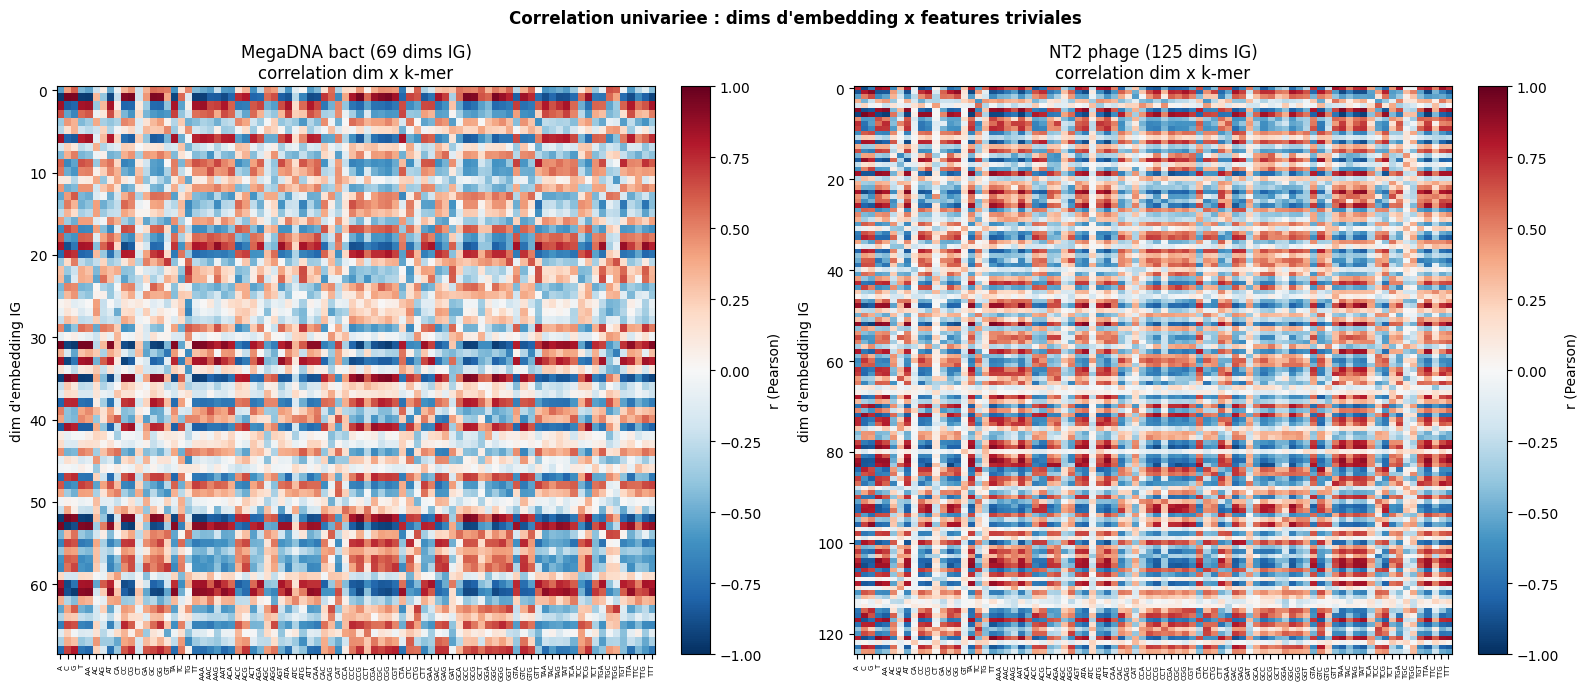

Pour chaque dim d'embedding : |r| max avec un k-mer
  bact  : mediane=0.66  | |r|>0.5 : 58/69 (84%)  | |r|>0.7 : 30/69 (43%)
          features les plus souvent dominantes : {'GTT': 7, 'TG': 7, 'C': 5}
  phage : mediane=0.71  | |r|>0.5 : 97/125 (78%)  | |r|>0.7 : 64/125 (51%)
          features les plus souvent dominantes : {'TT': 11, 'C': 8, 'G': 7}


In [13]:
# Correlation univariee : chaque dim d'embedding x chaque feature triviale
def corr_emb_triv(emb_sel, triv_df):
    feats = list(triv_df.columns)
    C = np.zeros((emb_sel.shape[1], len(feats)))
    for i in range(emb_sel.shape[1]):
        for j, f in enumerate(feats):
            col = triv_df[f].values
            C[i, j] = 0.0 if np.std(col) == 0 else np.corrcoef(emb_sel[:, i], col)[0, 1]
    return C, feats

C_bact,  feats_b = corr_emb_triv(bact_emb_sel,  bact_triv)
C_phage, feats_p = corr_emb_triv(phage_emb_sel, phage_triv)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, C, feats, title in [
    (axes[0], C_bact,  feats_b, f"MegaDNA bact ({len(bact_dims_ig)} dims IG)"),
    (axes[1], C_phage, feats_p, f"NT2 phage ({len(phage_dims_ig)} dims IG)"),
]:
    im = ax.imshow(C, vmin=-1, vmax=1, cmap="RdBu_r", aspect="auto")
    ax.set_xticks(range(len(feats)))
    ax.set_xticklabels(feats, rotation=90, fontsize=5)
    ax.set_ylabel("dim d'embedding IG")
    ax.set_title(f"{title}\ncorrelation dim x k-mer")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="r (Pearson)")
plt.suptitle("Correlation univariee : dims d'embedding x features triviales", fontweight="bold")
plt.tight_layout()
plt.show()

print("Pour chaque dim d'embedding : |r| max avec un k-mer")
for name, C, feats in [("bact", C_bact, feats_b), ("phage", C_phage, feats_p)]:
    ma = np.abs(C).max(axis=1)
    # feature triviale la plus souvent dominante
    dominant = pd.Series([feats[k] for k in np.abs(C).argmax(axis=1)]).value_counts().head(3)
    print(f"  {name:5s} : mediane={np.median(ma):.2f}  "
          f"| |r|>0.5 : {(ma>0.5).sum()}/{len(ma)} ({100*(ma>0.5).mean():.0f}%)  "
          f"| |r|>0.7 : {(ma>0.7).sum()}/{len(ma)} ({100*(ma>0.7).mean():.0f}%)")
    print(f"          features les plus souvent dominantes : {dict(dominant)}")

In [14]:
# Helper commun : histogramme de la distribution du R2 (deja max Ridge/RF) par item.
# items = liste de (r2_array, titre) ; thresholds = seuils a tracer ; ylabel = "N (dims)" ou "N (features)".
def plot_recon_dist(items, xlabel, suptitle, thresholds=(0.7,), ylabel="N (dims)"):
    _col = {0.5: "red", 0.7: "grey"}
    fig, axes = plt.subplots(1, len(items), figsize=(7 * len(items), 4))
    axes = np.atleast_1d(axes)
    for ax, (r2, title) in zip(axes, items):
        r2 = np.asarray(r2, float)
        r2 = r2[~np.isnan(r2)]
        ax.hist(np.clip(r2, -0.2, 1), bins=25, color="#8172B3", alpha=0.8)
        for thr in thresholds:
            ax.axvline(thr, color=_col.get(thr, "grey"), ls="--", lw=0.8, label=f"seuil {thr}")
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(f"{title} ({len(r2)}) - med={np.median(r2):.2f}")
        ax.legend(fontsize=8)
    plt.suptitle(suptitle, fontweight="bold")
    plt.tight_layout()
    plt.show()


Calcul de la reconstructibilite ...


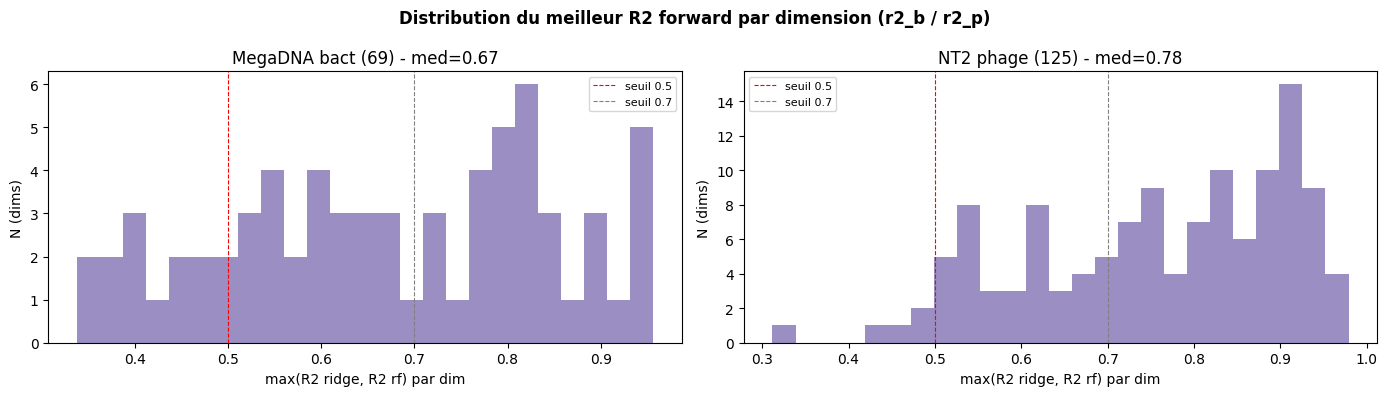

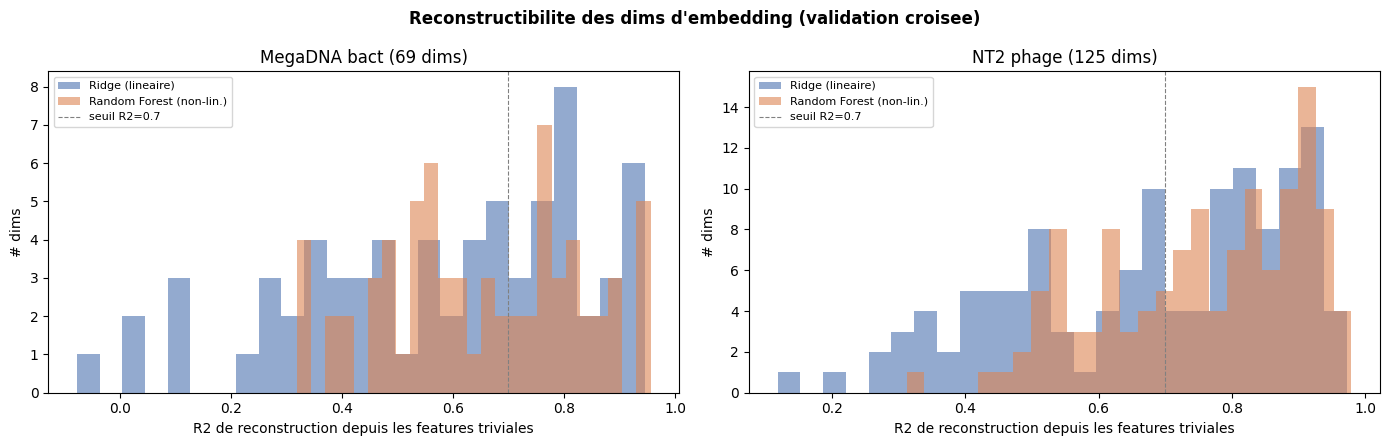


Reconstructibilite R2 (validation croisee) :

  bact (69 dims) :
    Ridge (lineaire)    : R2 median=0.64  | dims R2>0.7 : 27/69 (39%)
    RandomForest (n-l.) : R2 median=0.67  | dims R2>0.7 : 31/69 (45%)
    trivial (R2>0.7)   : 33/69 (48%)
    moyen  [0.5-0.7]   : 22/69 (32%)
    deep    (R2<0.5)   : 14/69 (20%)

  phage (125 dims) :
    Ridge (lineaire)    : R2 median=0.72  | dims R2>0.7 : 65/125 (52%)
    RandomForest (n-l.) : R2 median=0.78  | dims R2>0.7 : 84/125 (67%)
    trivial (R2>0.7)   : 84/125 (67%)
    moyen  [0.5-0.7]   : 36/125 (29%)
    deep    (R2<0.5)   : 5/125 (4%)

Decoupage trivial/moyen/deep sauvegarde dans output/pbip/small2/ig30/trivial/


In [15]:
def reconstructibility(emb_sel, triv_df, n_estimators=60, cv=3):
    """R2 (CV) de reconstruction de chaque dim d'embedding depuis les features triviales."""
    X = triv_df.values
    r2_ridge, r2_rf = [], []
    for i in range(emb_sel.shape[1]):
        y = emb_sel[:, i]
        ridge = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
        rf    = RandomForestRegressor(n_estimators=n_estimators, n_jobs=-1, random_state=0)
        r2_ridge.append(cross_val_score(ridge, X, y, cv=cv, scoring="r2").mean())
        r2_rf.append(cross_val_score(rf,    X, y, cv=cv, scoring="r2").mean())
    return np.array(r2_ridge), np.array(r2_rf)

print("Calcul de la reconstructibilite ...")
r2_ridge_b, r2_rf_b = reconstructibility(bact_emb_sel,  bact_triv)
r2_ridge_p, r2_rf_p = reconstructibility(phage_emb_sel, phage_triv)
r2_b = np.maximum(r2_ridge_b, r2_rf_b)   # meilleur R2 forward par dim (ridge ou rf)
r2_p = np.maximum(r2_ridge_p, r2_rf_p)
plot_recon_dist(
    [(r2_b, "MegaDNA bact"), (r2_p, "NT2 phage")],
    "max(R2 ridge, R2 rf) par dim",
    "Distribution du meilleur R2 forward par dimension (r2_b / r2_p)",
    thresholds=(0.5, 0.7),
)




fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, rr, rf_, title in [
    (axes[0], r2_ridge_b, r2_rf_b, f"MegaDNA bact ({len(bact_dims_ig)} dims)"),
    (axes[1], r2_ridge_p, r2_rf_p, f"NT2 phage ({len(phage_dims_ig)} dims)"),
]:
    ax.hist(np.clip(rr, -0.2, 1), bins=25, alpha=0.6, color="#4C72B0", label="Ridge (lineaire)")
    ax.hist(np.clip(rf_, -0.2, 1), bins=25, alpha=0.6, color="#DD8452", label="Random Forest (non-lin.)")
    ax.axvline(0.7, color="grey", ls="--", lw=0.8, label="seuil R2=0.7")
    ax.set_xlabel("R2 de reconstruction depuis les features triviales")
    ax.set_ylabel("# dims")
    ax.set_title(title)
    ax.legend(fontsize=8)
plt.suptitle("Reconstructibilite des dims d'embedding (validation croisee)", fontweight="bold")
plt.tight_layout()
plt.show()

# --- Synthese detaillee + sauvegarde du decoupage trivial/deep ---
# Classement en 3 zones selon le meilleur R2 forward par dim (max Ridge/RF) :
#   trivial  R2 > TRIV_THR  -> reconstructible depuis les k-mers (composition)
#   moyen    entre les deux -> partiellement composition
#   deep     R2 < DEEP_THR  -> peu reconstructible -> signal non trivial
TRIV_THR, DEEP_THR = 0.7, 0.5
out_dir = f"{IG_DIR}/trivial"
os.makedirs(out_dir, exist_ok=True)

print("\nReconstructibilite R2 (validation croisee) :")
for nm, rr, rf_, dims in [("bact",  r2_ridge_b, r2_rf_b, bact_dims_ig),
                          ("phage", r2_ridge_p, r2_rf_p, phage_dims_ig)]:
    n = len(dims)
    r2m     = np.maximum(rr, rf_)        # meilleur R2 forward par dim
    trivial = r2m > TRIV_THR             # bien reconstructible -> composition
    deep    = r2m < DEEP_THR             # peu reconstructible -> signal non trivial
    moyen   = ~trivial & ~deep           # entre les deux
    print(f"\n  {nm} ({n} dims) :")
    print(f"    Ridge (lineaire)    : R2 median={np.median(rr):.2f}  "
          f"| dims R2>0.7 : {(rr>0.7).sum()}/{n} ({100*(rr>0.7).mean():.0f}%)")
    print(f"    RandomForest (n-l.) : R2 median={np.median(rf_):.2f}  "
          f"| dims R2>0.7 : {(rf_>0.7).sum()}/{n} ({100*(rf_>0.7).mean():.0f}%)")
    print(f"    trivial (R2>{TRIV_THR})   : {trivial.sum()}/{n} ({100*trivial.mean():.0f}%)")
    print(f"    moyen  [{DEEP_THR}-{TRIV_THR}]   : {moyen.sum()}/{n} ({100*moyen.mean():.0f}%)")
    print(f"    deep    (R2<{DEEP_THR})   : {deep.sum()}/{n} ({100*deep.mean():.0f}%)")
    np.save(f"{out_dir}/{nm}_dims_trivial.npy", dims[trivial])
    np.save(f"{out_dir}/{nm}_dims_moyen.npy",   dims[moyen])
    np.save(f"{out_dir}/{nm}_dims_deep.npy",    dims[deep])

print(f"\nDecoupage trivial/moyen/deep sauvegarde dans {out_dir}/")

### 9b. Sens inverse : reconstruire les features triviales depuis l'embedding

L'inverse du sens direct : ici `X` = embeddings (dims IG), `y` = chaque fréquence k-mer. Un R² élevé signifie que le foundation model a **capturé cette feature** dans sa représentation. À lire avec une nuance : ce sens a souvent des R² plus hauts (un embedding de nombreuses dims a beaucoup de capacité pour reconstruire **une** feature triviale).

Calcul de la reconstruction inverse (feature triviale <- embedding) ...


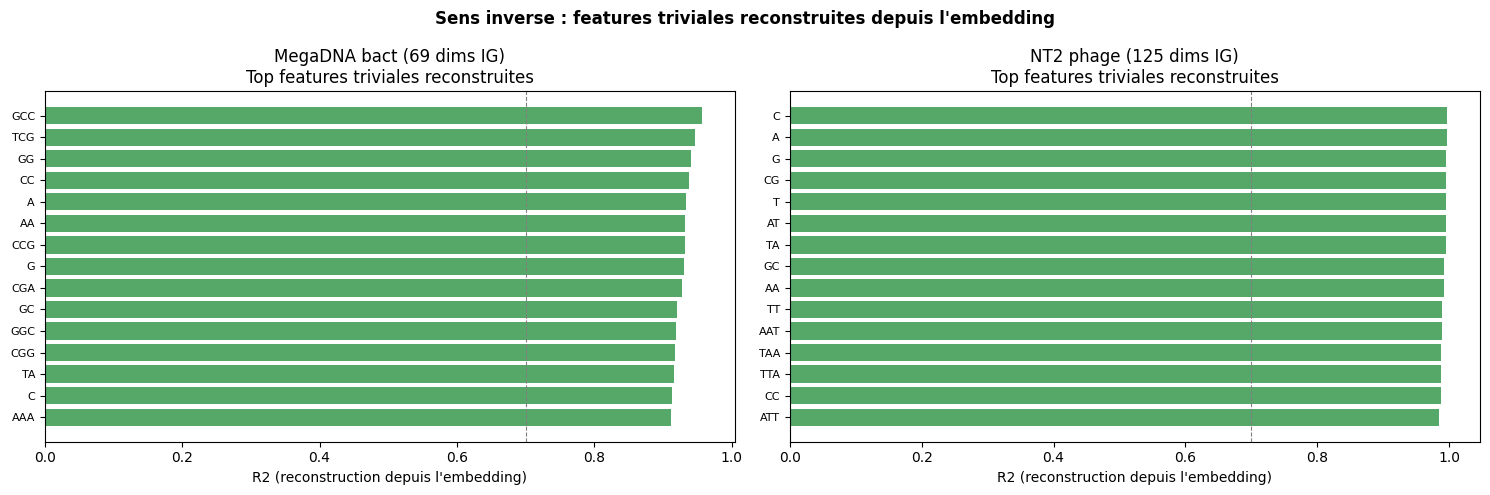


Synthese (meilleur des 2 modeles Ridge/RF) :
  bact  : R2 median=0.85 | features R2>0.7 : 72/84
  phage : R2 median=0.95 | features R2>0.7 : 84/84


In [16]:
# 9b. Reconstruire CHAQUE feature triviale depuis les embeddings (sens inverse de la cellule d'avant).
# Version vectorisee multi-sortie : Ridge/RF fit UNE fois par fold pour TOUTES les cibles a la
# fois (pas une regression par feature) -> rapide meme avec des milliers de features (k=4,5,6...).
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

def reconstruct_cv(X, Y, cv=3, n_estimators=60):
    """R2 (CV) multi-sortie de reconstruction de toutes les colonnes de Y depuis X."""
    X, Y = np.asarray(X, float), np.asarray(Y, float)
    kf = KFold(cv, shuffle=True, random_state=0)
    pr, pf = np.zeros_like(Y), np.zeros_like(Y)
    for tr, te in kf.split(X):
        sc = StandardScaler().fit(X[tr])
        pr[te] = Ridge(alpha=1.0, solver="svd").fit(sc.transform(X[tr]), Y[tr]).predict(sc.transform(X[te]))
        pf[te] = RandomForestRegressor(n_estimators=n_estimators, n_jobs=-1,
                                       random_state=0).fit(X[tr], Y[tr]).predict(X[te])
    r2r = r2_score(Y, pr, multioutput="raw_values")
    r2f = r2_score(Y, pf, multioutput="raw_values")
    return r2r, r2f

def triv_from_emb(emb_sel, triv_df):
    """R2 (CV) de reconstruction de chaque feature triviale depuis les embeddings (via reconstruct_cv)."""
    Y = triv_df.values.astype(float)
    ok = Y.std(axis=0) > 0                       # colonnes constantes -> R2 indefini (NaN)
    r2_ridge = np.full(Y.shape[1], np.nan)
    r2_rf    = np.full(Y.shape[1], np.nan)
    rr, rf = reconstruct_cv(emb_sel, Y[:, ok])
    r2_ridge[ok], r2_rf[ok] = rr, rf
    return pd.DataFrame({"r2_ridge": r2_ridge, "r2_rf": r2_rf}, index=triv_df.columns)

print("Calcul de la reconstruction inverse (feature triviale <- embedding) ...")
triv_b = triv_from_emb(bact_emb_sel,  bact_triv)
triv_p = triv_from_emb(phage_emb_sel, phage_triv)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, t, title in [(axes[0], triv_b, f"MegaDNA bact ({len(bact_dims_ig)} dims IG)"),
                     (axes[1], triv_p, f"NT2 phage ({len(phage_dims_ig)} dims IG)")]:
    best = t.max(axis=1).dropna().sort_values(ascending=False).head(15)  # meilleur des 2 modeles
    ax.barh(range(len(best)), best.values, color="#55A868")
    ax.set_yticks(range(len(best)))
    ax.set_yticklabels(best.index, fontsize=8)
    ax.invert_yaxis()
    ax.axvline(0.7, color="grey", ls="--", lw=0.8)
    ax.set_xlabel("R2 (reconstruction depuis l'embedding)")
    ax.set_title(f"{title}\nTop features triviales reconstruites")
plt.suptitle("Sens inverse : features triviales reconstruites depuis l'embedding",
             fontweight="bold")
plt.tight_layout()
plt.show()

print("\nSynthese (meilleur des 2 modeles Ridge/RF) :")
for nm, t in [("bact", triv_b), ("phage", triv_p)]:
    best = t.max(axis=1)
    print(f"  {nm:5s} : R2 median={best.median():.2f} "
          f"| features R2>0.7 : {(best > 0.7).sum()}/{best.notna().sum()}")


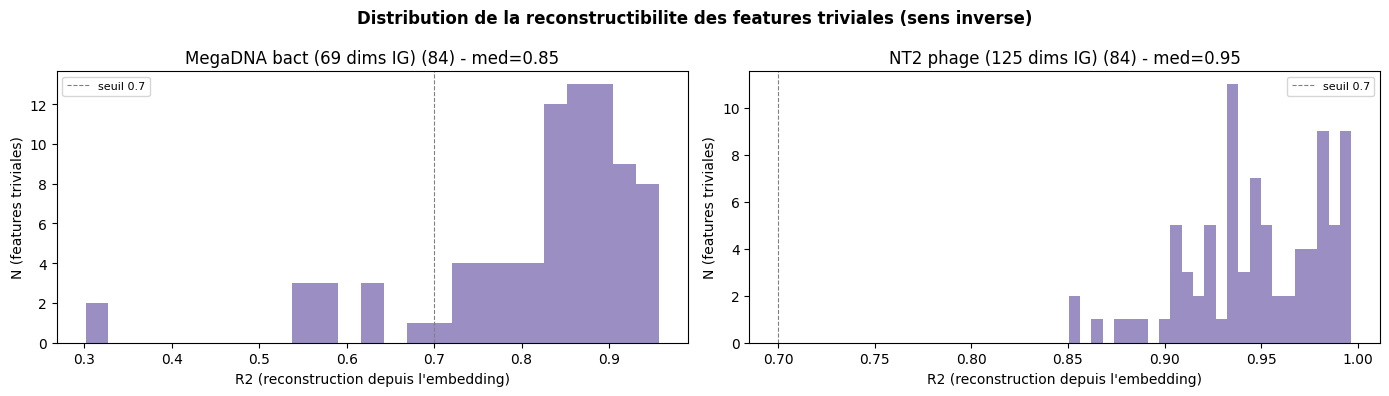

In [17]:
# Distribution N(R2) : combien de features triviales atteignent quel R2 (meilleur Ridge/RF).
plot_recon_dist(
    [(triv_b.max(axis=1), f"MegaDNA bact ({len(bact_dims_ig)} dims IG)"),
     (triv_p.max(axis=1), f"NT2 phage ({len(phage_dims_ig)} dims IG)")],
    "R2 (reconstruction depuis l'embedding)",
    "Distribution de la reconstructibilite des features triviales (sens inverse)",
    ylabel="N (features triviales)",
)


### 9c. Sens inverse, mais depuis les seules dimensions « deep »

Idem 9b, sauf que `X` ne contient plus que les dimensions jugées **non triviales** en 9 (`~((rr>0.7)|(rf>0.7))`, masque aligné sur les colonnes de `*_emb_sel`). Question décisive : ces dims « deep » — celles que les k-mers **ne** reconstruisent **pas** — encodent-elles malgré tout la composition k-mer ? Si oui, la composition imprègne même le résidu « profond » ; si non, ces dims portent un signal réellement indépendant des k-mers.

Dims deep (non triviales) : bact 14/69 | phage 5/125


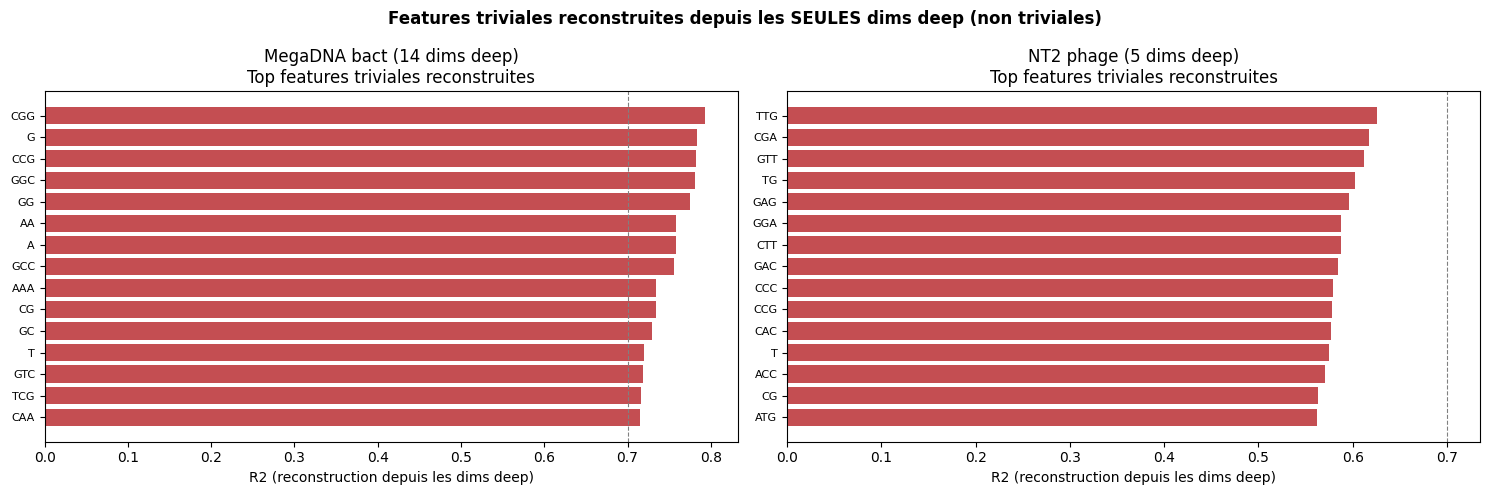


Synthese (dims deep seules, meilleur des 2 modeles) :
  bact  : R2 median=0.63 | features R2>0.7 : 21/84
  phage : R2 median=0.50 | features R2>0.7 : 0/84


In [18]:
# 9c. Idem 9b mais X = uniquement les dims jugees NON triviales (deep) en 9.
deep_b = r2_b < 0.5   # dims peu reconstructibles depuis les k-mers (max ridge/rf < seuil)
deep_p = r2_p < 0.5
print(f"Dims deep (non triviales) : bact {deep_b.sum()}/{len(deep_b)} | "
      f"phage {deep_p.sum()}/{len(deep_p)}")

assert deep_b.sum() > 0 and deep_p.sum() > 0, "aucune dim deep : rien a reconstruire"
triv_b_deep = triv_from_emb(bact_emb_sel[:,  deep_b], bact_triv)
triv_p_deep = triv_from_emb(phage_emb_sel[:, deep_p], phage_triv)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, t, title in [(axes[0], triv_b_deep, f"MegaDNA bact ({deep_b.sum()} dims deep)"),
                     (axes[1], triv_p_deep, f"NT2 phage ({deep_p.sum()} dims deep)")]:
    best = t.max(axis=1).dropna().sort_values(ascending=False).head(15)  # meilleur des 2 modeles
    ax.barh(range(len(best)), best.values, color="#C44E52")
    ax.set_yticks(range(len(best)))
    ax.set_yticklabels(best.index, fontsize=8)
    ax.invert_yaxis()
    ax.axvline(0.7, color="grey", ls="--", lw=0.8)
    ax.set_xlabel("R2 (reconstruction depuis les dims deep)")
    ax.set_title(f"{title}\nTop features triviales reconstruites")
plt.suptitle("Features triviales reconstruites depuis les SEULES dims deep (non triviales)",
             fontweight="bold")
plt.tight_layout()
plt.show()

print("\nSynthese (dims deep seules, meilleur des 2 modeles) :")
for nm, t in [("bact", triv_b_deep), ("phage", triv_p_deep)]:
    best = t.max(axis=1)
    print(f"  {nm:5s} : R2 median={best.median():.2f} "
          f"| features R2>0.7 : {(best > 0.7).sum()}/{best.notna().sum()}")


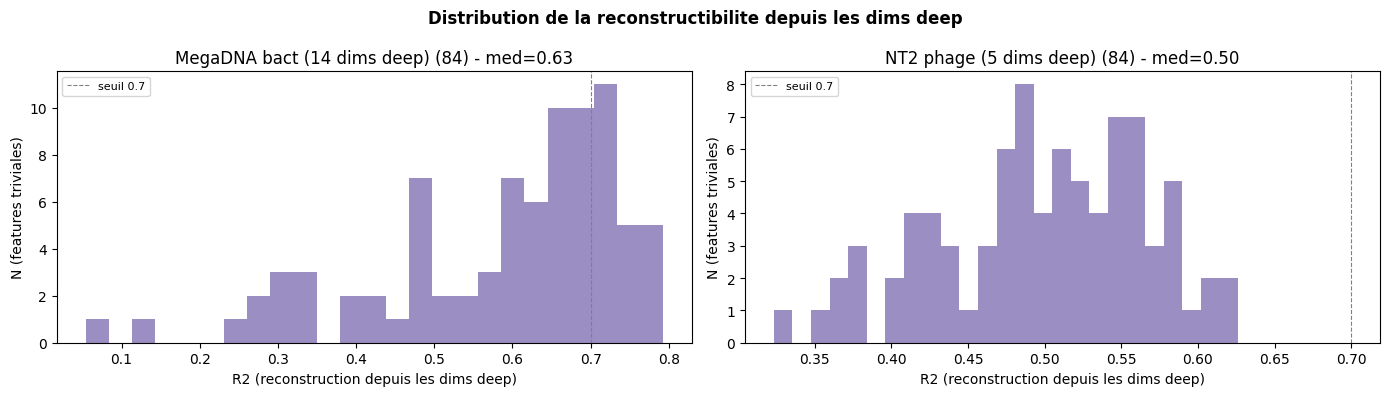

In [19]:
# Distribution N(R2) pour le sens inverse depuis les SEULES dims deep.
plot_recon_dist(
    [(triv_b_deep.max(axis=1), f"MegaDNA bact ({deep_b.sum()} dims deep)"),
     (triv_p_deep.max(axis=1), f"NT2 phage ({deep_p.sum()} dims deep)")],
    "R2 (reconstruction depuis les dims deep)",
    "Distribution de la reconstructibilite depuis les dims deep",
    ylabel="N (features triviales)",
)


Dims triviales disponibles : bact 33 | phage 84
Tirage aleatoire (meme nb que deep) : bact 14 | phage 5


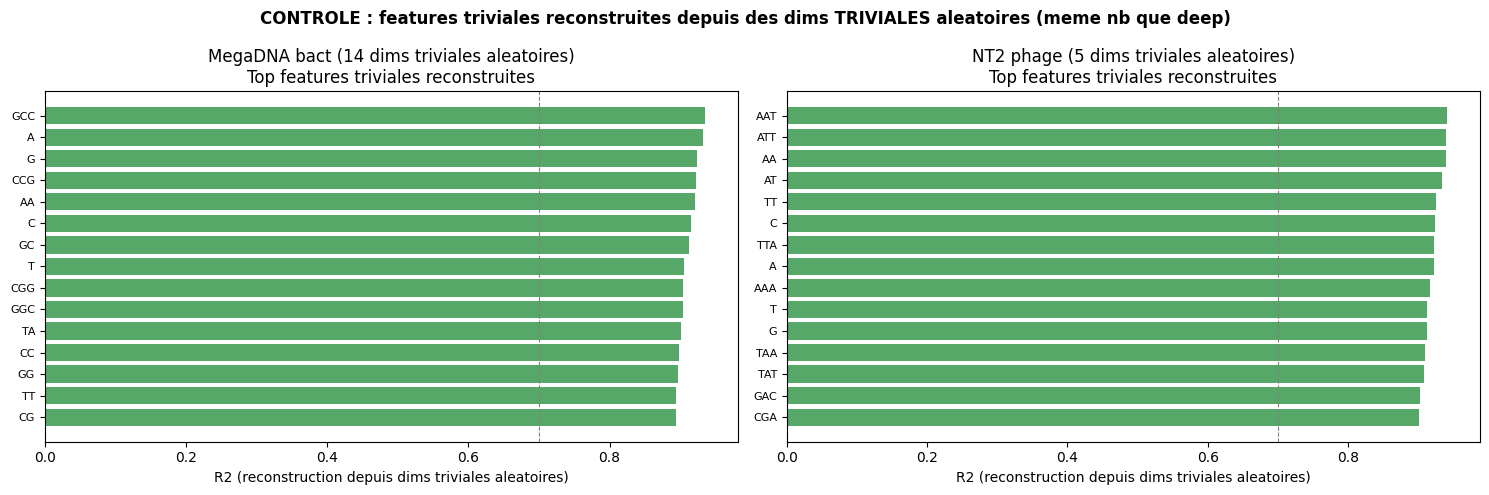


Synthese (dims triviales aleatoires, meilleur des 2 modeles) :
  bact  : R2 median=0.80 | features R2>0.7 : 60/84
  phage : R2 median=0.78 | features R2>0.7 : 61/84

Comparaison R2 median des features triviales reconstruites (deep vs trivial-aleatoire) :
  bact  : deep=0.63   trivial-aleatoire=0.80
  phage : deep=0.50   trivial-aleatoire=0.78


In [20]:
# 9c-bis. CONTROLE : meme nb de dims que "deep" mais tirees AU HASARD parmi les dims TRIVIALES
# (r2 > TRIV_THR, bien reconstructibles depuis les k-mers). Si les dims deep portent vraiment moins
# d'info triviale, reconstruire les features triviales doit etre MEILLEUR ici que depuis les dims deep.
rng = np.random.default_rng(0)
triv_idx_b = np.where(r2_b > TRIV_THR)[0]   # indices des dims triviales (dans bact_emb_sel)
triv_idx_p = np.where(r2_p > TRIV_THR)[0]
print(f"Dims triviales disponibles : bact {len(triv_idx_b)} | phage {len(triv_idx_p)}")
assert len(triv_idx_b) >= int(deep_b.sum()) and len(triv_idx_p) >= int(deep_p.sum()), \
    "pas assez de dims triviales pour egaler le nb de dims deep"
rand_triv_b = rng.choice(triv_idx_b, size=int(deep_b.sum()), replace=False)
rand_triv_p = rng.choice(triv_idx_p, size=int(deep_p.sum()), replace=False)
print(f"Tirage aleatoire (meme nb que deep) : bact {len(rand_triv_b)} | phage {len(rand_triv_p)}")

triv_b_rtriv = triv_from_emb(bact_emb_sel[:,  rand_triv_b], bact_triv)
triv_p_rtriv = triv_from_emb(phage_emb_sel[:, rand_triv_p], phage_triv)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, t, title in [(axes[0], triv_b_rtriv, f"MegaDNA bact ({len(rand_triv_b)} dims triviales aleatoires)"),
                     (axes[1], triv_p_rtriv, f"NT2 phage ({len(rand_triv_p)} dims triviales aleatoires)")]:
    best = t.max(axis=1).dropna().sort_values(ascending=False).head(15)  # meilleur des 2 modeles
    ax.barh(range(len(best)), best.values, color="#55A868")
    ax.set_yticks(range(len(best)))
    ax.set_yticklabels(best.index, fontsize=8)
    ax.invert_yaxis()
    ax.axvline(0.7, color="grey", ls="--", lw=0.8)
    ax.set_xlabel("R2 (reconstruction depuis dims triviales aleatoires)")
    ax.set_title(f"{title}\nTop features triviales reconstruites")
plt.suptitle("CONTROLE : features triviales reconstruites depuis des dims TRIVIALES aleatoires "
             "(meme nb que deep)", fontweight="bold")
plt.tight_layout()
plt.show()

print("\nSynthese (dims triviales aleatoires, meilleur des 2 modeles) :")
for nm, t in [("bact", triv_b_rtriv), ("phage", triv_p_rtriv)]:
    best = t.max(axis=1)
    print(f"  {nm:5s} : R2 median={best.median():.2f} "
          f"| features R2>0.7 : {(best > 0.7).sum()}/{best.notna().sum()}")

print("\nComparaison R2 median des features triviales reconstruites (deep vs trivial-aleatoire) :")
for nm, td, tr in [("bact", triv_b_deep, triv_b_rtriv), ("phage", triv_p_deep, triv_p_rtriv)]:
    print(f"  {nm:5s} : deep={td.max(axis=1).median():.2f}   "
          f"trivial-aleatoire={tr.max(axis=1).median():.2f}")

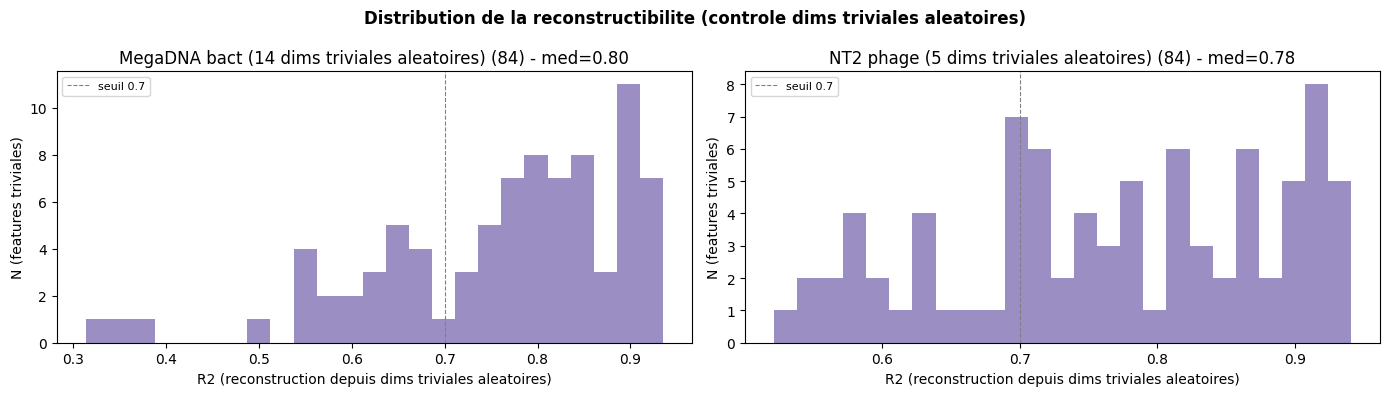

In [21]:
# Distribution N(R2) pour le controle (dims triviales aleatoires, meme nb que deep).
plot_recon_dist(
    [(triv_b_rtriv.max(axis=1), f"MegaDNA bact ({len(rand_triv_b)} dims triviales aleatoires)"),
     (triv_p_rtriv.max(axis=1), f"NT2 phage ({len(rand_triv_p)} dims triviales aleatoires)")],
    "R2 (reconstruction depuis dims triviales aleatoires)",
    "Distribution de la reconstructibilite (controle dims triviales aleatoires)",
    ylabel="N (features triviales)",
)


### 9d. Reconstructibilité des dimensions NON sélectionnées par IG30

Même analyse forward que la cellule de reconstructibilité, mais sur le **complément** : toutes les dimensions de l'embedding **hors IG30** (`setdiff(range(dim_totale), dims_ig)`). Question : les dimensions que le modèle **utilise** pour décider (IG) sont-elles plus, ou moins, reconstructibles depuis la composition k-mer que le reste de l'embedding ? Calcul vectorisé via `reconstruct_cv` (sinon des centaines de dims × CV seraient lentes).

Dims NON-IG : bact 895 | phage 643


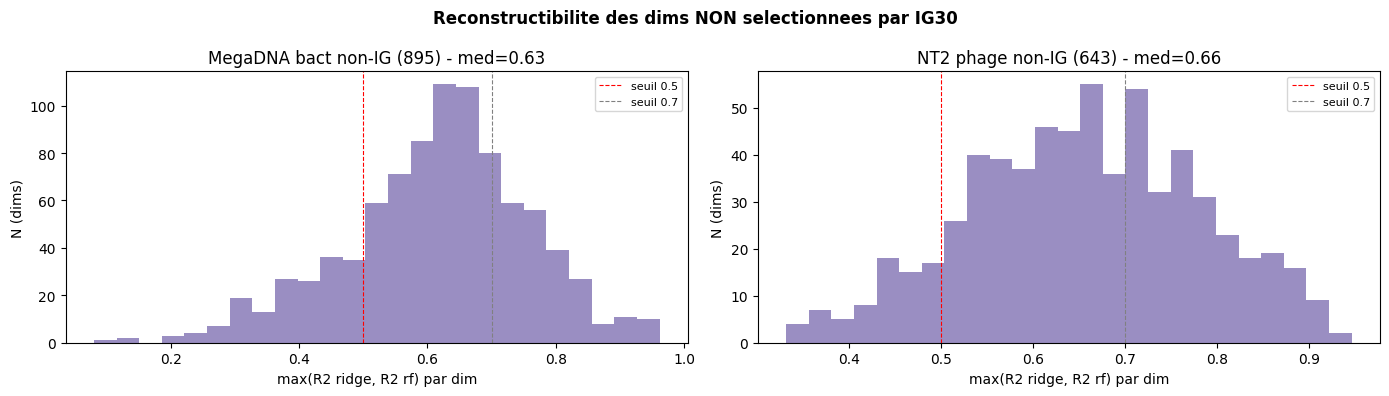


3 zones (dims non-IG) :
  bact  (895 dims) : trivial>0.7=245 (27%)  moyen=481 (54%)  deep<0.5=169 (19%)  | R2 median=0.63
  phage (643 dims) : trivial>0.7=247 (38%)  moyen=324 (50%)  deep<0.5=72 (11%)  | R2 median=0.66

Comparaison IG vs non-IG (R2 forward median) :
  bact  : IG=0.67   non-IG=0.63
  phage : IG=0.78   non-IG=0.66

Dims deep non-IG (R2<0.5) : bact 169 | phage 72
Dims deep TOTALES (IG + non-IG, R2<0.5) : bact 183 | phage 77 -> sauvegarde dans output/pbip/small2/ig30/trivial/


In [22]:
# 9d. Reconstructibilite forward sur les dims de l'embedding NON selectionnees par IG30.
def nonig_emb_and_triv(ent_df, dims_ig):
    """(embeddings sur les dims NON-IG, features triviales) alignes par entite."""
    e = ent_df[ent_df["emb"].notna()]
    full = np.stack(e["emb"].values)
    non_ig = np.setdiff1d(np.arange(full.shape[1]), dims_ig)
    triv = e[KMER_COLS].copy()  # noms inutilises ici (.values)
    return full[:, non_ig], triv, non_ig

bact_emb_nig,  bact_triv_nig,  bact_dims_nig  = nonig_emb_and_triv(dtr["bacteria"], bact_dims_ig)
phage_emb_nig, phage_triv_nig, phage_dims_nig = nonig_emb_and_triv(dtr["phages"],   phage_dims_ig)
print(f"Dims NON-IG : bact {len(bact_dims_nig)} | phage {len(phage_dims_nig)}")

# Forward vectorise : X = features triviales -> Y = dims non-IG (une passe pour toutes les dims).
r2r_b, r2f_b = reconstruct_cv(bact_triv_nig.values,  bact_emb_nig)
r2r_p, r2f_p = reconstruct_cv(phage_triv_nig.values, phage_emb_nig)
r2_b_nig = np.maximum(r2r_b, r2f_b)
r2_p_nig = np.maximum(r2r_p, r2f_p)

plot_recon_dist(
    [(r2_b_nig, "MegaDNA bact non-IG"), (r2_p_nig, "NT2 phage non-IG")],
    "max(R2 ridge, R2 rf) par dim",
    "Reconstructibilite des dims NON selectionnees par IG30",
    thresholds=(0.5, 0.7),
)

print("\n3 zones (dims non-IG) :")
for nm, r2m in [("bact", r2_b_nig), ("phage", r2_p_nig)]:
    n = len(r2m)
    triv = int((r2m > TRIV_THR).sum()); deep = int((r2m < DEEP_THR).sum()); moy = n - triv - deep
    print(f"  {nm:5s} ({n} dims) : trivial>{TRIV_THR}={triv} ({100*triv/n:.0f}%)  "
          f"moyen={moy} ({100*moy/n:.0f}%)  deep<{DEEP_THR}={deep} ({100*deep/n:.0f}%)  "
          f"| R2 median={np.median(r2m):.2f}")

print("\nComparaison IG vs non-IG (R2 forward median) :")
for nm, ig, nig in [("bact", r2_b, r2_b_nig), ("phage", r2_p, r2_p_nig)]:
    print(f"  {nm:5s} : IG={np.median(ig):.2f}   non-IG={np.median(nig):.2f}")

# --- Dims deep (R2<DEEP_THR) parmi les non-IG, en indices d'embedding complet ---
deep_nig_b = bact_dims_nig[r2_b_nig < DEEP_THR]
deep_nig_p = phage_dims_nig[r2_p_nig < DEEP_THR]
print(f"\nDims deep non-IG (R2<{DEEP_THR}) : bact {len(deep_nig_b)} | phage {len(deep_nig_p)}")

# Union avec les dims deep DANS IG30 (sauvees en 9) -> toutes les dims deep
TRIV_DIR = f"{IG_DIR}/trivial"
alldeep_b = np.union1d(np.load(f"{TRIV_DIR}/bact_dims_deep.npy"),  deep_nig_b)
alldeep_p = np.union1d(np.load(f"{TRIV_DIR}/phage_dims_deep.npy"), deep_nig_p)
np.save(f"{TRIV_DIR}/bact_dims_alldeep.npy",  alldeep_b)
np.save(f"{TRIV_DIR}/phage_dims_alldeep.npy", alldeep_p)
print(f"Dims deep TOTALES (IG + non-IG, R2<{DEEP_THR}) : "
      f"bact {len(alldeep_b)} | phage {len(alldeep_p)} -> sauvegarde dans {TRIV_DIR}/")


### 9e. Reconstruire les k-mers depuis les SEULES dims `alldeep`

Test decisif pour le sous-ensemble `alldeep` (deep IG + deep non-IG), celui qui
generalise le mieux sur `all` (MCC ~ 0.36). Si les k-mers **ne** se reconstruisent
**pas** depuis ces dims, alors leur generalisation ne vient pas de la composition
(le biais k-mer de `all`) mais d'un signal reellement non trivial. `X` = embeddings
restreints aux dims `alldeep`, `y` = chaque frequence k-mer (sens inverse, multi-sortie).

Dims alldeep : bact 183 | phage 77


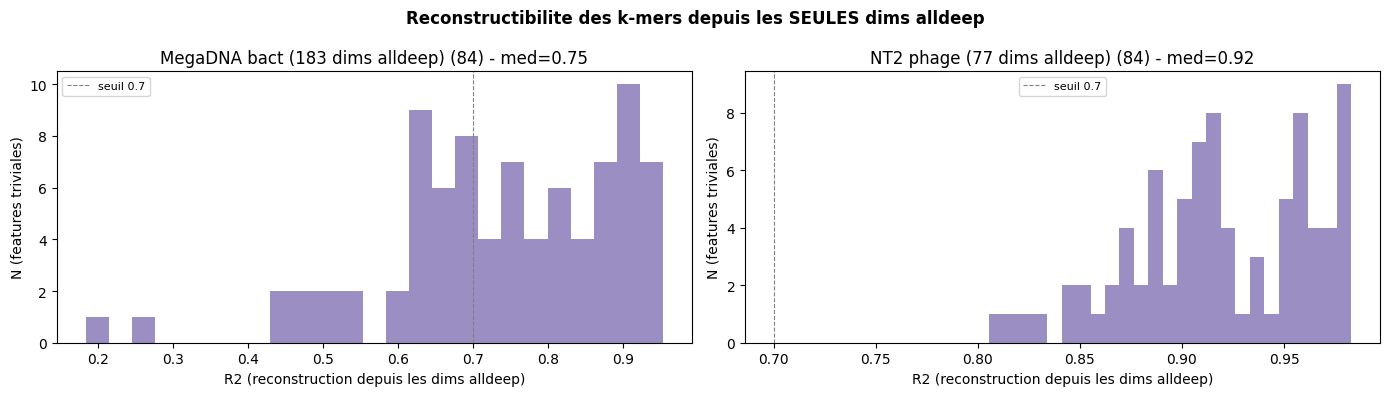


Synthese (k-mers <- alldeep, meilleur des 2 modeles) :
  bact  : R2 median=0.75 | features R2>0.7 : 50/84
  phage : R2 median=0.92 | features R2>0.7 : 84/84


In [23]:
# 9e. Sens inverse depuis TOUTES les dims deep (alldeep = deep IG + deep non-IG),
# soit exactement les dims du sous-ensemble `alldeep` reentraine plus bas (MCC ~0.36 sur all).
# Si les k-mers ne se reconstruisent pas depuis ces dims, leur generalisation n'est pas
# portee par la composition (biais k-mer de `all`).
def emb_dims_and_triv(ent_df, dims):
    """(embeddings restreints a `dims` sur l'embedding COMPLET, features triviales) par entite."""
    e = ent_df[ent_df["emb"].notna()]
    full = np.stack(e["emb"].values)
    return full[:, dims], e[KMER_COLS].copy()

alldeep_b = np.load(f"{TRIV_DIR}/bact_dims_alldeep.npy")
alldeep_p = np.load(f"{TRIV_DIR}/phage_dims_alldeep.npy")
print(f"Dims alldeep : bact {len(alldeep_b)} | phage {len(alldeep_p)}")

b_ad_emb, b_ad_triv = emb_dims_and_triv(dtr["bacteria"], alldeep_b)
p_ad_emb, p_ad_triv = emb_dims_and_triv(dtr["phages"],   alldeep_p)

triv_b_alldeep = triv_from_emb(b_ad_emb, b_ad_triv)
triv_p_alldeep = triv_from_emb(p_ad_emb, p_ad_triv)

plot_recon_dist(
    [(triv_b_alldeep.max(axis=1), f"MegaDNA bact ({len(alldeep_b)} dims alldeep)"),
     (triv_p_alldeep.max(axis=1), f"NT2 phage ({len(alldeep_p)} dims alldeep)")],
    "R2 (reconstruction depuis les dims alldeep)",
    "Reconstructibilite des k-mers depuis les SEULES dims alldeep",
    ylabel="N (features triviales)",
)

print("\nSynthese (k-mers <- alldeep, meilleur des 2 modeles) :")
for nm, t in [("bact", triv_b_alldeep), ("phage", triv_p_alldeep)]:
    best = t.max(axis=1)
    print(f"  {nm:5s} : R2 median={best.median():.2f} "
          f"| features R2>0.7 : {(best > 0.7).sum()}/{best.notna().sum()}")


In [ ]:
# 9f. Recapitulatif sur l'embedding small2 COMPLET (dims IG + dims non-IG).
# Meme decoupage en 3 zones que le tableau des dims IG, mais sur la totalite de
# l'embedding : 964 dims bact (MegaDNA) + 768 dims phage (NT2).
# NB : r2_*  = max(Ridge, RF) sur les dims IG ; r2_*_nig = idem sur les dims non-IG.
print(f"{'cote':6s} {'dims':>5s} {'R2 med':>7s} {'triviale >0.7':>16s} "
      f"{'moyenne 0.5-0.7':>17s} {'profonde <0.5':>16s}")
for nm, r2_ig, r2_nig in [("bact", r2_b, r2_b_nig), ("phage", r2_p, r2_p_nig)]:
    r2m  = np.concatenate([r2_ig, r2_nig])
    n    = len(r2m)
    triv = int((r2m > TRIV_THR).sum())
    deep = int((r2m < DEEP_THR).sum())
    moy  = n - triv - deep
    print(f"{nm:6s} {n:5d} {np.median(r2m):7.2f} "
          f"{triv:6d} ({100*triv/n:3.0f} %) {moy:8d} ({100*moy/n:3.0f} %) "
          f"{deep:7d} ({100*deep/n:3.0f} %)")

## 10. PBIP réentraîné : dimensions triviales vs profondes

On réentraîne le classifieur PBIP sur 3 sous-ensembles de dimensions de `small2` :
`ig30_full` (194 dims), `ig30_trivial`, `ig30_deep`. Question : le signal
généralisable est-il dans les dims triviales ou profondes ?

In [24]:
import torch
_orig_load = torch.load
def _load_compat(*a, **k):
    k.setdefault("weights_only", False)
    return _orig_load(*a, **k)
torch.load = _load_compat

from pbi_utils.data_manager import H5pyEmbeddingsManager, PerphectDataInput
from pbi_utils.config_parser import InputConfig
from main import parse_config, make_dataset, train_nn_model
from sklearn.metrics import f1_score

device = "cuda" if torch.cuda.is_available() else "cpu"
config_s2 = parse_config(config_path="output/pbip/small2/training_config.yaml")
BN = [m.name() for m in config_s2.bacteria_embedding_models]
PN = [m.name() for m in config_s2.phages_embedding_models]

def load_pbip_dataset(couples_csv, bact_csv, phage_csv, emb_dir):
    inp = InputConfig(bacteria_df=bact_csv, phages_df=phage_csv, couples_df=couples_csv)
    _, _, cdf = PerphectDataInput(input_paths=inp).load()
    return make_dataset(cdf, BN, PN, H5pyEmbeddingsManager(emb_dir), device)

ds_tr  = load_pbip_dataset(f"{PRED}/predphi_train_dataset.csv",
                           f"{PRED}/bacteria_sequences.csv",
                           f"{PRED}/bacteriophages_sequences.csv", "data/embeddings-pbip")
ds_pp  = load_pbip_dataset(f"{PRED}/predphi_test_dataset.csv",
                           f"{PRED}/bacteria_sequences.csv",
                           f"{PRED}/bacteriophages_sequences.csv", "data/embeddings-pbip")
ds_all = load_pbip_dataset(f"{ALL}/couples_df.csv", f"{ALL}/bacteria_df.csv",
                           f"{ALL}/phages_df.csv", "data/embeddings")
print(f"datasets PBIP : train={len(ds_tr)} predphi={len(ds_pp)} all={len(ds_all)}")

[INFO] Configuration loaded from output/pbip/small2/training_config.yaml: Config(input_perphect=bacteria_df='data/perphect-data/predphi/bacteria_sequences.csv' phages_df='data/perphect-data/predphi/bacteriophages_sequences.csv' couples_df='data/perphect-data/predphi/predphi_train_dataset.csv', embeddings_dir=data/embeddings-pbip, num_gpu=1, gpu_id=0, training_config=TrainingConfig(do_train=True do_test=False epochs=100 batch_size=256 learning_rate=0.001 weight_decay=0.0001 training_noise_std=0.05 stratify_cv=True k_folds_cv=1 patience_early_stopping=1000 monitor_metric_early_stopping='f1' patience_reduce_lr=1000 monitor_metric_reduce_lr='f1' multiplying_factor_reduce_lr=0.5 reduce_dimensionality='none' n_components_bacteria=None n_components_phages=None), phages_embedding_models=[NT2(merging_strategy=TruncateStrategy(), overlap=0, model_name='nucleotide-transformer-v2-250m-multi-species')], compute_phages_embeddings=[True], bacteria_embedding_models=[MegaDNA(merging_strategy=TruncateSt

Loading embeddings:   0%|          | 0/5702 [00:00<?, ?it/s]

[DEBUG] Loading 5702 embeddings for model NT2-TruncateStrategy-250M-ov0 from data/embeddings-pbip


Loading embeddings:   0%|          | 0/5702 [00:00<?, ?it/s]

[DEBUG] Final embedding size (bacteria): 964
[DEBUG] Final embedding size (phages): 768
[INFO] Perphect input files will be read from data/perphect-data/predphi/bacteria_sequences.csv, data/perphect-data/predphi/bacteriophages_sequences.csv and data/perphect-data/predphi/predphi_test_dataset.csv
[INFO] Reading csv files...
[INFO] Embeddings will be stored or read from data/embeddings-pbip
[INFO] Creating dataset (loading embeddings)...
[DEBUG] Loading 1236 embeddings for model MegaDNA-TruncateStrategy-concat-ov0 from data/embeddings-pbip


...

[DEBUG] Final embedding size (bacteria): 964
[DEBUG] Final embedding size (phages): 768
[INFO] Perphect input files will be read from data/perphect-data/all/bacteria_df.csv, data/perphect-data/all/phages_df.csv and data/perphect-data/all/couples_df.csv
[INFO] Reading csv files...
[INFO] Embeddings will be stored or read from data/embeddings
[INFO] Creating dataset (loading embeddings)...
[DEBUG] Loading 7720 embeddings for model MegaDNA-TruncateStrategy-concat-ov0 from data/embeddings


Loading embeddings:   0%|          | 0/7720 [00:00<?, ?it/s]

[DEBUG] Loading 7720 embeddings for model NT2-TruncateStrategy-250M-ov0 from data/embeddings


Loading embeddings:   0%|          | 0/7720 [00:00<?, ?it/s]

[DEBUG] Final embedding size (bacteria): 964
[DEBUG] Final embedding size (phages): 768
datasets PBIP : train=5702 predphi=1236 all=7720


In [25]:
def select_dims(ds, bd, pd_):
    ds2 = ds.copy()
    ds2["bacterium_embedding"] = [e[bd].float() for e in ds["bacterium_embedding"]]
    ds2["phage_embedding"]     = [e[pd_].float() for e in ds["phage_embedding"]]
    return ds2

import copy

def train_pbip(ds_train, noise_std=None):
    bs = len(ds_train["bacterium_embedding"].iloc[0])
    ps = len(ds_train["phage_embedding"].iloc[0])
    m = config_s2.classifier(bs, ps, **config_s2.classifier_params).to(device)
    tcfg = config_s2.training_config
    if noise_std is not None:                 # override du training_noise_std
        tcfg = copy.deepcopy(tcfg)
        tcfg.training_noise_std = noise_std
    train_nn_model(ds_train, m, tcfg, device=device, verbose=0)
    m.eval()
    return m

def eval_pbip(m, ds):
    preds, labels = [], []
    with torch.no_grad():
        for _, row in ds.iterrows():
            out = m(row["bacterium_embedding"].unsqueeze(0).to(device),
                    row["phage_embedding"].unsqueeze(0).to(device))
            preds.append(int(out.argmax(dim=1).item()))
            labels.append(int(row["interaction_type"]))
    preds, labels = np.array(preds), np.array(labels)
    return {"mcc": matthews_corrcoef(labels, preds),
            "f1": f1_score(labels, preds, zero_division=0)}

TRIV_DIR = f"{IG_DIR}/trivial"
variants = {
    "ig30_full":    (np.load(f"{IG_DIR}/bact_dims.npy"),  np.load(f"{IG_DIR}/phage_dims.npy")),
    "ig30_trivial": (np.load(f"{TRIV_DIR}/bact_dims_trivial.npy"),
                     np.load(f"{TRIV_DIR}/phage_dims_trivial.npy")),
    "ig30_deep":    (np.load(f"{TRIV_DIR}/bact_dims_deep.npy"),
                     np.load(f"{TRIV_DIR}/phage_dims_deep.npy")),
    "alldeep":      (np.load(f"{TRIV_DIR}/bact_dims_alldeep.npy"),
                     np.load(f"{TRIV_DIR}/phage_dims_alldeep.npy")),
}

N_RUNS = 10
pbip_records = []
for name, (bd, pd_) in variants.items():
    s_tr  = select_dims(ds_tr,  bd, pd_)
    s_pp  = select_dims(ds_pp,  bd, pd_)
    s_all = select_dims(ds_all, bd, pd_)
    print(f"=== {name} ({len(bd)+len(pd_)} dims) ===")
    for run in range(N_RUNS):
        m = train_pbip(s_tr)
        for split, mm in [("predphi", eval_pbip(m, s_pp)), ("all", eval_pbip(m, s_all))]:
            pbip_records.append({"config": name, "run": run, "split": split, **mm})
    sub = pd.DataFrame(pbip_records)
    sub = sub[sub.config == name]
    for sp in ("predphi", "all"):
        v = sub[sub.split == sp]["mcc"]
        print(f"  {sp:8s} MCC {v.mean():.3f} ± {v.std():.3f}")

df_pbip = pd.DataFrame(pbip_records)

=== ig30_full (194 dims) ===
  predphi  MCC 0.556 ± 0.014
  all      MCC 0.292 ± 0.024
=== ig30_trivial (117 dims) ===
  predphi  MCC 0.549 ± 0.025
  all      MCC 0.289 ± 0.013
=== ig30_deep (19 dims) ===
  predphi  MCC 0.157 ± 0.029
  all      MCC 0.281 ± 0.009
=== alldeep (260 dims) ===
  predphi  MCC 0.443 ± 0.031
  all      MCC 0.350 ± 0.012


## 11. PBIP-MLP sur k-mers vs sur embeddings

On entraîne le **même classifieur MLP PBIP** mais avec les fréquences k-mer
en entrée au lieu des embeddings. À classifieur identique, on isole l'apport
réel du foundation model.

In [26]:
def kmer_pbip_dataset(d):
    """Dataset PBIP ou les 'embeddings' sont les vecteurs k-mer (84 dims/cote)."""
    # On sous-selectionne les colonnes k-mer (float) AVANT d'indexer, sinon une
    # ligne issue du DataFrame complet (texte + float) ressort en dtype object.
    b = d["bacteria"].set_index("bacterium_id")[KMER_COLS].astype(np.float32)
    p = d["phages"].set_index("phage_id")[KMER_COLS].astype(np.float32)
    rows = []
    for c in d["couples"].itertuples():
        if c.bacterium_id in b.index and c.phage_id in p.index:
            rows.append({
                "bacterium_embedding": torch.tensor(b.loc[c.bacterium_id].values,
                                                    dtype=torch.float32),
                "phage_embedding":     torch.tensor(p.loc[c.phage_id].values,
                                                    dtype=torch.float32),
                "interaction_type":    int(c.interaction_type),
            })
    return pd.DataFrame(rows)

km_tr  = kmer_pbip_dataset(datasets["predphi_train"])
km_pp  = kmer_pbip_dataset(datasets["predphi_test"])
km_all = kmer_pbip_dataset(datasets["all"])
print(f"datasets k-mer : train={len(km_tr)} predphi={len(km_pp)} all={len(km_all)}")




km_records = []
for run in range(N_RUNS):
    m = train_pbip(km_tr)
    for split, mm in [("predphi", eval_pbip(m, km_pp)), ("all", eval_pbip(m, km_all))]:
        km_records.append({"config": "pbip_kmers", "run": run, "split": split, **mm})
df_km = pd.DataFrame(km_records)

print("\nPBIP-MLP : k-mers vs embeddings (ig30_full)")
for sp in ("predphi", "all"):
    k = df_km[df_km.split == sp]["mcc"]
    e = df_pbip[(df_pbip.config == "ig30_full") & (df_pbip.split == sp)]["mcc"]
    print(f"  {sp:8s} | k-mers {k.mean():.3f}+/-{k.std():.3f} "
          f"| embeddings {e.mean():.3f}+/-{e.std():.3f} | delta={e.mean()-k.mean():+.3f}")

datasets k-mer : train=5702 predphi=1236 all=7720

PBIP-MLP : k-mers vs embeddings (ig30_full)
  predphi  | k-mers 0.520+/-0.011 | embeddings 0.556+/-0.014 | delta=+0.036
  all      | k-mers 0.233+/-0.006 | embeddings 0.292+/-0.024 | delta=+0.059


## 12. Récapitulatif : sous-ensembles de dimensions d'embedding vs k-mers

MCC du PBIP réentraîné selon le sous-ensemble de dimensions (full / trivial / deep / alldeep) et, en comparaison, le **PBIP entraîné sur les k-mers** (section 13). Même classifieur, mêmes runs.

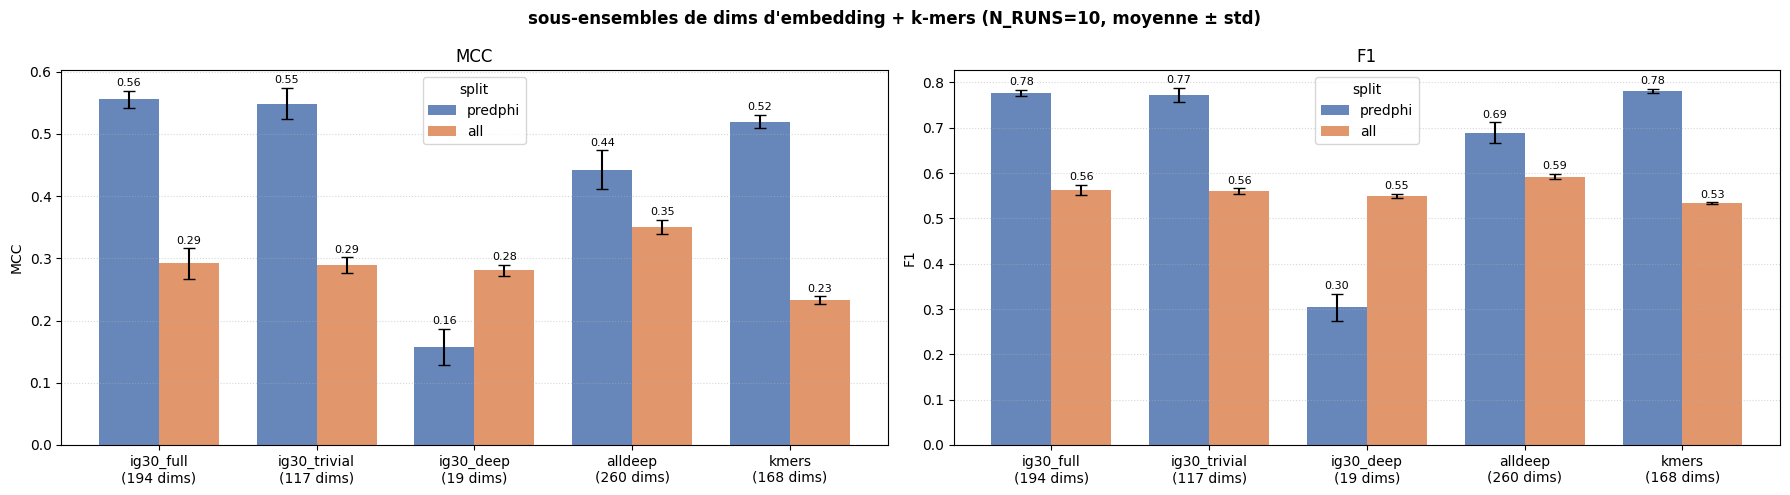

In [27]:
# Plot recapitulatif combiné : MCC (gauche) et F1 (droite) par sous-ensemble de dims + k-mers.
allres = pd.concat([df_pbip, df_km], ignore_index=True)
allres["config"] = allres["config"].replace({"pbip_kmers": "kmers"})
ndims = {c: len(variants[c][0]) + len(variants[c][1]) for c in variants}
ndims["kmers"] = 2 * len(KMER_COLS)               # 84 k-mers x 2 cotes
configs = list(variants) + ["kmers"]
splits  = ["predphi", "all"]
colors  = {"predphi": "#4C72B0", "all": "#DD8452"}
x, w = np.arange(len(configs)), 0.38

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for ax, metric in zip(axes, ["mcc", "f1"]):
    summary = allres.groupby(["config", "split"])[metric].agg(["mean", "std"]).reset_index()
    for k, sp in enumerate(splits):
        g = summary[summary.split == sp].set_index("config")
        means = [g.loc[c, "mean"] for c in configs]
        stds  = [g.loc[c, "std"]  for c in configs]
        bars  = ax.bar(x + (k - 0.5) * w, means, w, yerr=stds, capsize=4,
                       label=sp, color=colors[sp], alpha=0.85)
        ax.bar_label(bars, fmt="%.2f", fontsize=8, padding=2)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{c}\n({ndims[c]} dims)" for c in configs])
    ax.set_ylabel(metric.upper())
    ax.set_title(metric.upper())
    ax.axhline(0, color="grey", lw=0.6)
    ax.legend(title="split")
    ax.grid(axis="y", ls=":", alpha=0.5)
fig.suptitle(f"sous-ensembles de dims d'embedding + k-mers (N_RUNS={N_RUNS}, moyenne ± std)", fontweight="bold")
plt.tight_layout()
plt.show()